In [1]:
file_read = "001_fit"
file_write = "002_RMSE"

In [2]:
import polars as pl

df_train_val_preds = pl.read_parquet(f"{file_read}_train_val_preds.parquet")
df_test_preds = pl.read_parquet(f"{file_read}_test_preds.parquet")
df_coefs = pl.read_parquet(f"{file_read}_coefs.parquet")

In [3]:
column_target = "beta_av"
column_target_scaled = "beta_av_logit"
column_pred = f"{column_target}_pred"
column_pred_scaled = f"{column_target_scaled}_pred"

In [4]:
df_train_val_preds = df_train_val_preds.with_columns(
    (100 / (1 + (-pl.col(column_target_scaled)).exp())).alias(column_target),
    (100 / (1 + (-pl.col(column_pred_scaled)).exp())).alias(column_pred),
)

In [5]:
df_train_val_preds

pyridone_test,n_features,pyridone,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,i64,f64,f64,f64,f64
0,86,1,0,0.56851,0.563399,63.841924,63.723873
0,86,1,1,0.577178,0.475108,64.041771,61.659211
0,86,1,2,0.53889,0.416939,63.155406,60.275058
0,86,1,3,0.85113,0.442202,70.080418,60.878355
0,86,1,4,0.637598,0.430718,65.421028,60.604522
…,…,…,…,…,…,…,…
12,5,11,3,-0.486342,-0.15801,38.07556,46.057954
12,5,11,4,-0.441697,-0.147853,39.133657,46.310382
12,5,11,5,0.134649,-0.028059,53.361149,49.298568


In [6]:
df_train_val_rmse = (
    df_train_val_preds
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [7]:
df_train_val_rmse

n_features,beta_av_rmse
i32,f64
86,3.992931
85,3.992931
84,3.992931
83,3.992931
82,3.986729
…,…
9,4.269443
8,4.364103
7,4.54919


In [8]:
df_train_val_rmse_min = df_train_val_rmse.filter(
    pl.col(f"{column_target}_rmse") == pl.col(f"{column_target}_rmse").min()
)

In [9]:
df_train_val_rmse_min

n_features,beta_av_rmse
i32,f64
44,3.927055


In [10]:
n_features_min = df_train_val_rmse_min["n_features"][0]

In [11]:
df_test_preds = df_test_preds.with_columns(
    (100 / (1 + (-pl.col(column_target_scaled)).exp())).alias(column_target),
    (100 / (1 + (-pl.col(column_pred_scaled)).exp())).alias(column_pred),
)

In [12]:
df_test_preds

pyridone_test,n_features,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,f64,f64,f64,f64
0,86,0,0.055549,0.113355,51.388357,52.83084
0,86,1,0.061619,0.025064,51.539999,50.626561
0,86,2,-0.086761,-0.033105,47.832328,49.17244
0,86,3,-0.086245,-0.007843,47.845209,49.803932
0,86,4,-0.242775,-0.019326,43.960253,49.516863
…,…,…,…,…,…,…
12,5,3,-0.155744,-0.237074,46.114252,44.100754
12,5,4,-0.010116,-0.226918,49.74711,44.351275
12,5,5,-0.04161,-0.107123,48.959898,47.324474


In [13]:
df_test_rmse = (
    df_test_preds
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [14]:
df_test_rmse

n_features,beta_av_rmse
i32,f64
86,6.009646
85,6.009646
84,6.009646
83,6.009646
82,6.002563
…,…
9,6.480478
8,6.26153
7,6.259247


In [15]:
df_test_rmse_min = df_test_rmse.filter(pl.col("n_features") == n_features_min)

In [16]:
df_test_rmse_min

n_features,beta_av_rmse
i32,f64
44,6.180148


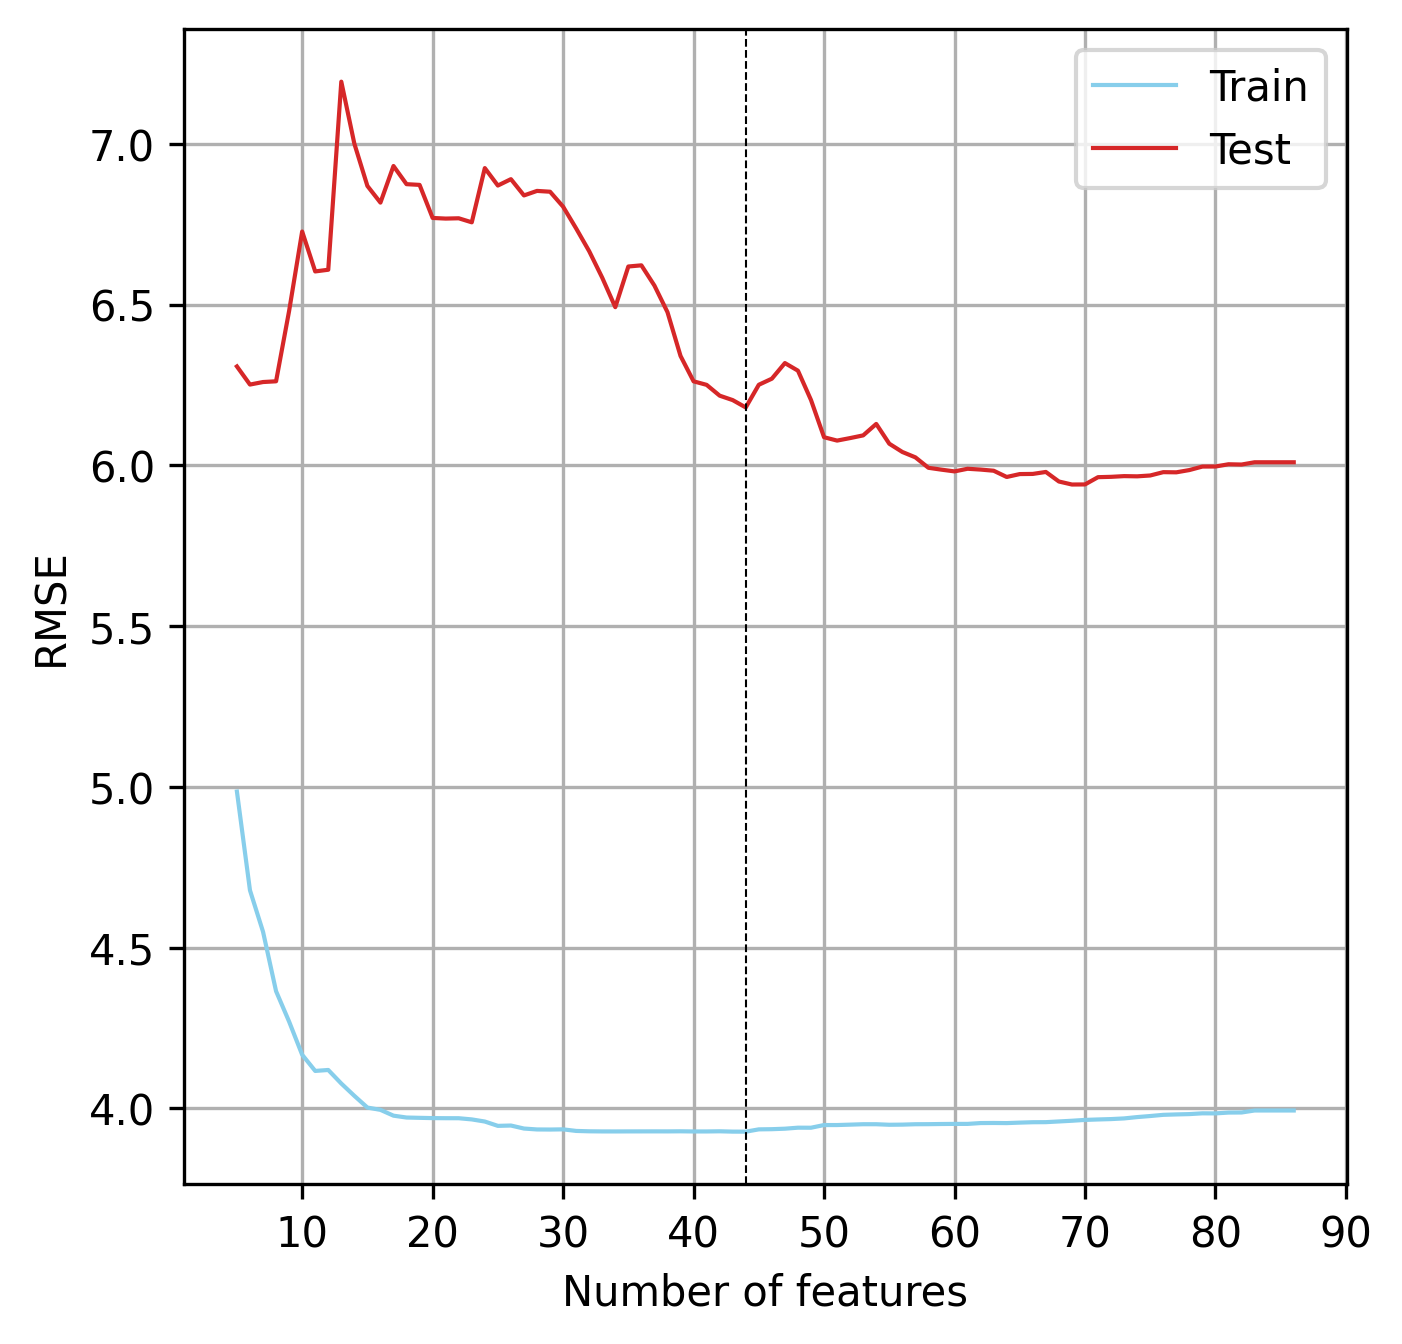

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(
    df_train_val_rmse["n_features"],
    df_train_val_rmse[f"{column_target}_rmse"],
    c="skyblue",
    label="Train",
    lw=1
)
ax.plot(
    df_test_rmse["n_features"],
    df_test_rmse[f"{column_target}_rmse"],
    c="tab:red",
    label="Test",
    lw=1
)
ax.axvline(
    n_features_min,
    c="black",
    lw=0.5,
    ls="--"
)

ax.set_xlabel("Number of features")
ax.set_ylabel("RMSE")

ax.grid()
ax.legend()

plt.savefig(
    f"{file_write}_plot.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [18]:
df_train_val_min = df_train_val_preds.filter(pl.col("n_features") == n_features_min)

In [19]:
df_train_val_min

pyridone_test,n_features,pyridone,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,i64,f64,f64,f64,f64
0,44,1,0,0.56851,0.588226,63.841924,64.295801
0,44,1,1,0.577178,0.533252,64.041771,63.024138
0,44,1,2,0.53889,0.474707,63.155406,61.649718
0,44,1,3,0.85113,0.498595,70.080418,62.212918
0,44,1,4,0.637598,0.502342,65.421028,62.300951
…,…,…,…,…,…,…,…
12,44,11,3,-0.486342,-0.325254,38.07556,41.939596
12,44,11,4,-0.441697,-0.346702,39.133657,41.418238
12,44,11,5,0.134649,-0.097989,53.361149,47.552228


In [20]:
df_test_min = df_test_preds.filter(pl.col("n_features") == n_features_min)

In [21]:
df_test_min

pyridone_test,n_features,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,f64,f64,f64,f64
0,44,0,0.055549,0.102698,51.388357,52.565203
0,44,1,0.061619,0.047725,51.539999,51.192892
0,44,2,-0.086761,-0.010821,47.832328,49.729478
0,44,3,-0.086245,0.013068,47.845209,50.326686
0,44,4,-0.242775,0.016814,43.960253,50.420343
…,…,…,…,…,…,…
12,44,3,-0.155744,-0.200313,46.114252,45.008853
12,44,4,-0.010116,-0.221762,49.74711,44.47857
12,44,5,-0.04161,0.026951,48.959898,50.673742


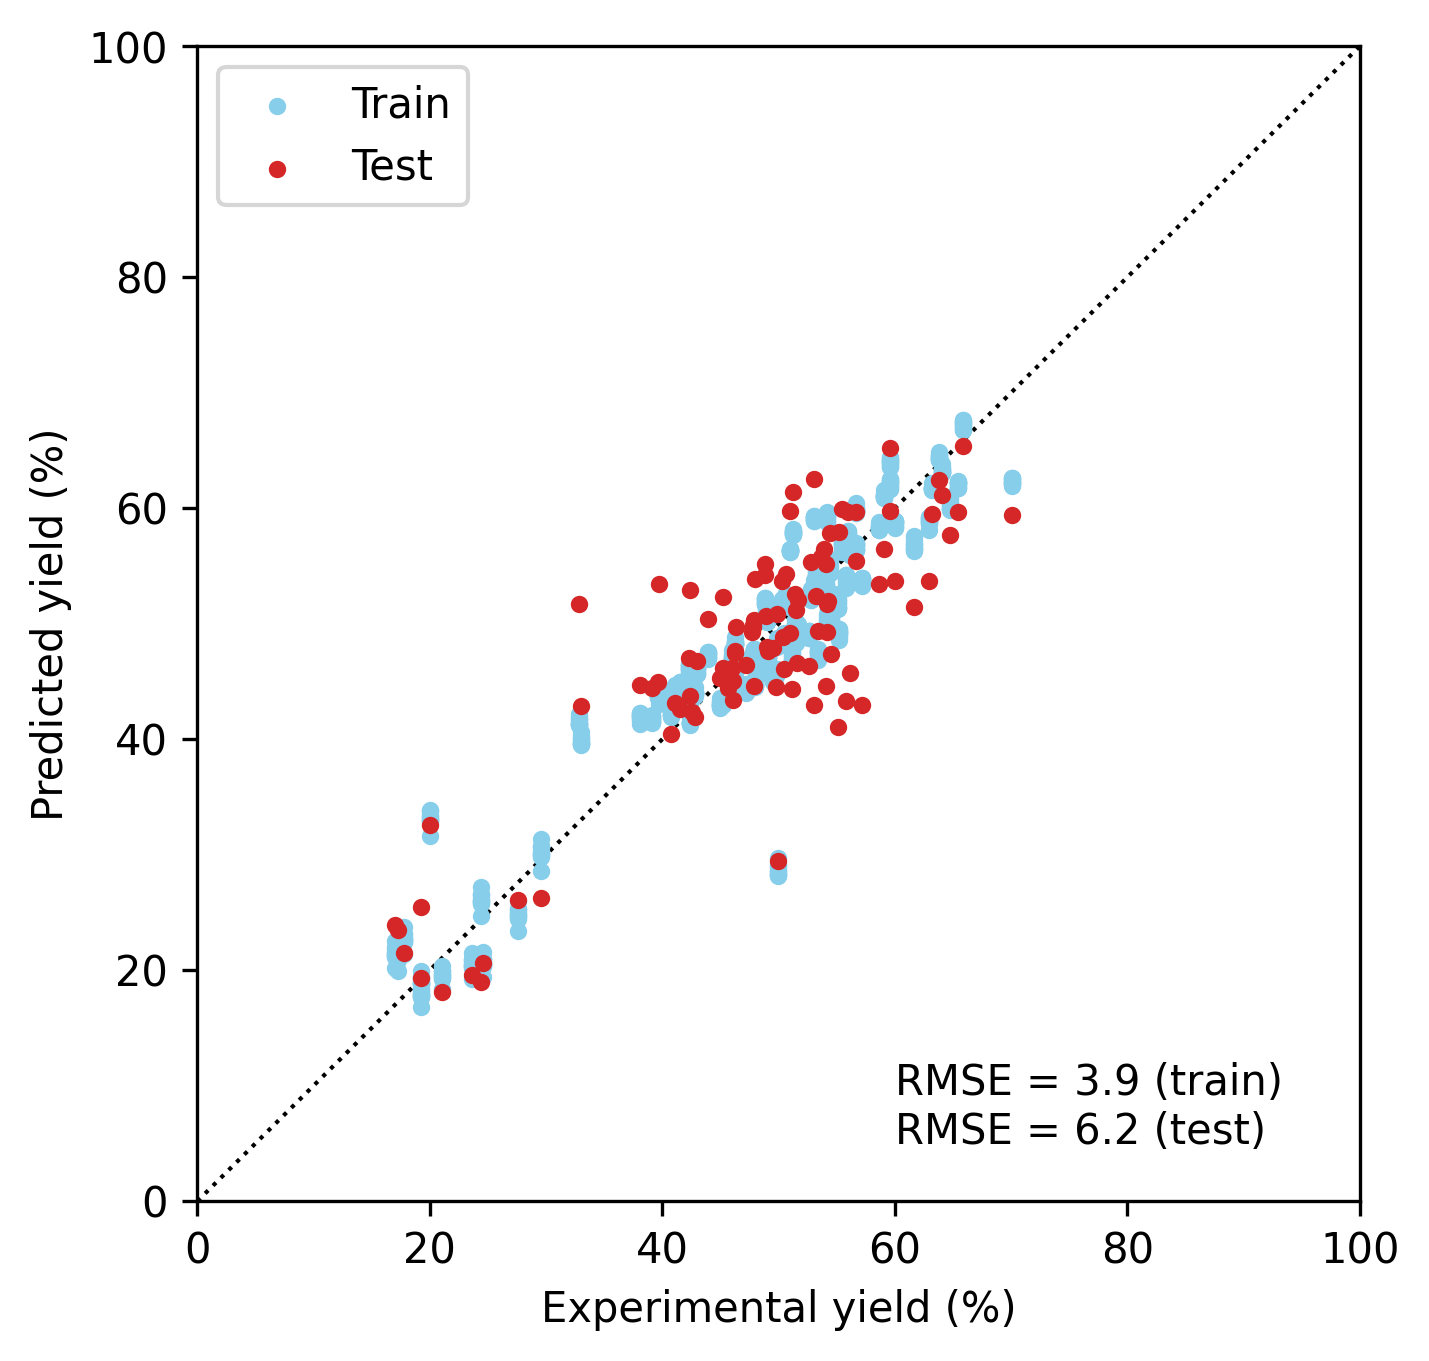

In [22]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(
    [0, 100],
    [0, 100],
    c="black",
    linestyle="dotted",
    lw=1,
    zorder=0
)
ax.scatter(
    df_train_val_min[column_target],
    df_train_val_min[column_pred],
    c="skyblue",
    label="Train",
    s=10,
    zorder=1
)
ax.scatter(
    df_test_min[column_target],
    df_test_min[column_pred],
    c="tab:red",
    label="Test",
    s=10,
    zorder=2
)

ax.set_xlabel("Experimental yield (%)")
ax.set_ylabel("Predicted yield (%)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

ax.legend()
ax.text(
    0.60, 0.05,
    f"RMSE = {df_train_val_rmse_min[f'{column_target}_rmse'][0]:1.1f} (train)\n"
    f"RMSE = {df_test_rmse_min[f'{column_target}_rmse'][0]:1.1f} (test)",
    transform=ax.transAxes
)

plt.savefig(
    f"{file_write}_scatter_all.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [23]:
column_group = "pyridone"

In [24]:
groups_test = df_test_preds[f"{column_group}_test"].unique(maintain_order=True)

In [25]:
groups_test

pyridone_test
i32
0
1
2
3
4
…
8
9
10


In [26]:
df_train_val_min

pyridone_test,n_features,pyridone,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,i64,f64,f64,f64,f64
0,44,1,0,0.56851,0.588226,63.841924,64.295801
0,44,1,1,0.577178,0.533252,64.041771,63.024138
0,44,1,2,0.53889,0.474707,63.155406,61.649718
0,44,1,3,0.85113,0.498595,70.080418,62.212918
0,44,1,4,0.637598,0.502342,65.421028,62.300951
…,…,…,…,…,…,…,…
12,44,11,3,-0.486342,-0.325254,38.07556,41.939596
12,44,11,4,-0.441697,-0.346702,39.133657,41.418238
12,44,11,5,0.134649,-0.097989,53.361149,47.552228


In [27]:
df_train_val_min_rmse = (
    df_train_val_min
    .group_by(f"{column_group}_test", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [28]:
df_train_val_min_rmse

pyridone_test,beta_av_rmse
i32,f64
0,4.01577
1,3.681964
2,3.99416
3,3.214399
4,4.047691
…,…
8,3.889082
9,4.006597
10,4.049605


In [29]:
df_test_min_rmse = (
    df_test_min
    .group_by(f"{column_group}_test", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [30]:
df_test_min_rmse

pyridone_test,beta_av_rmse
i32,f64
0,3.667258
1,6.89236
2,5.849566
3,9.77919
4,3.239638
…,…
8,10.156066
9,3.365416
10,3.155365


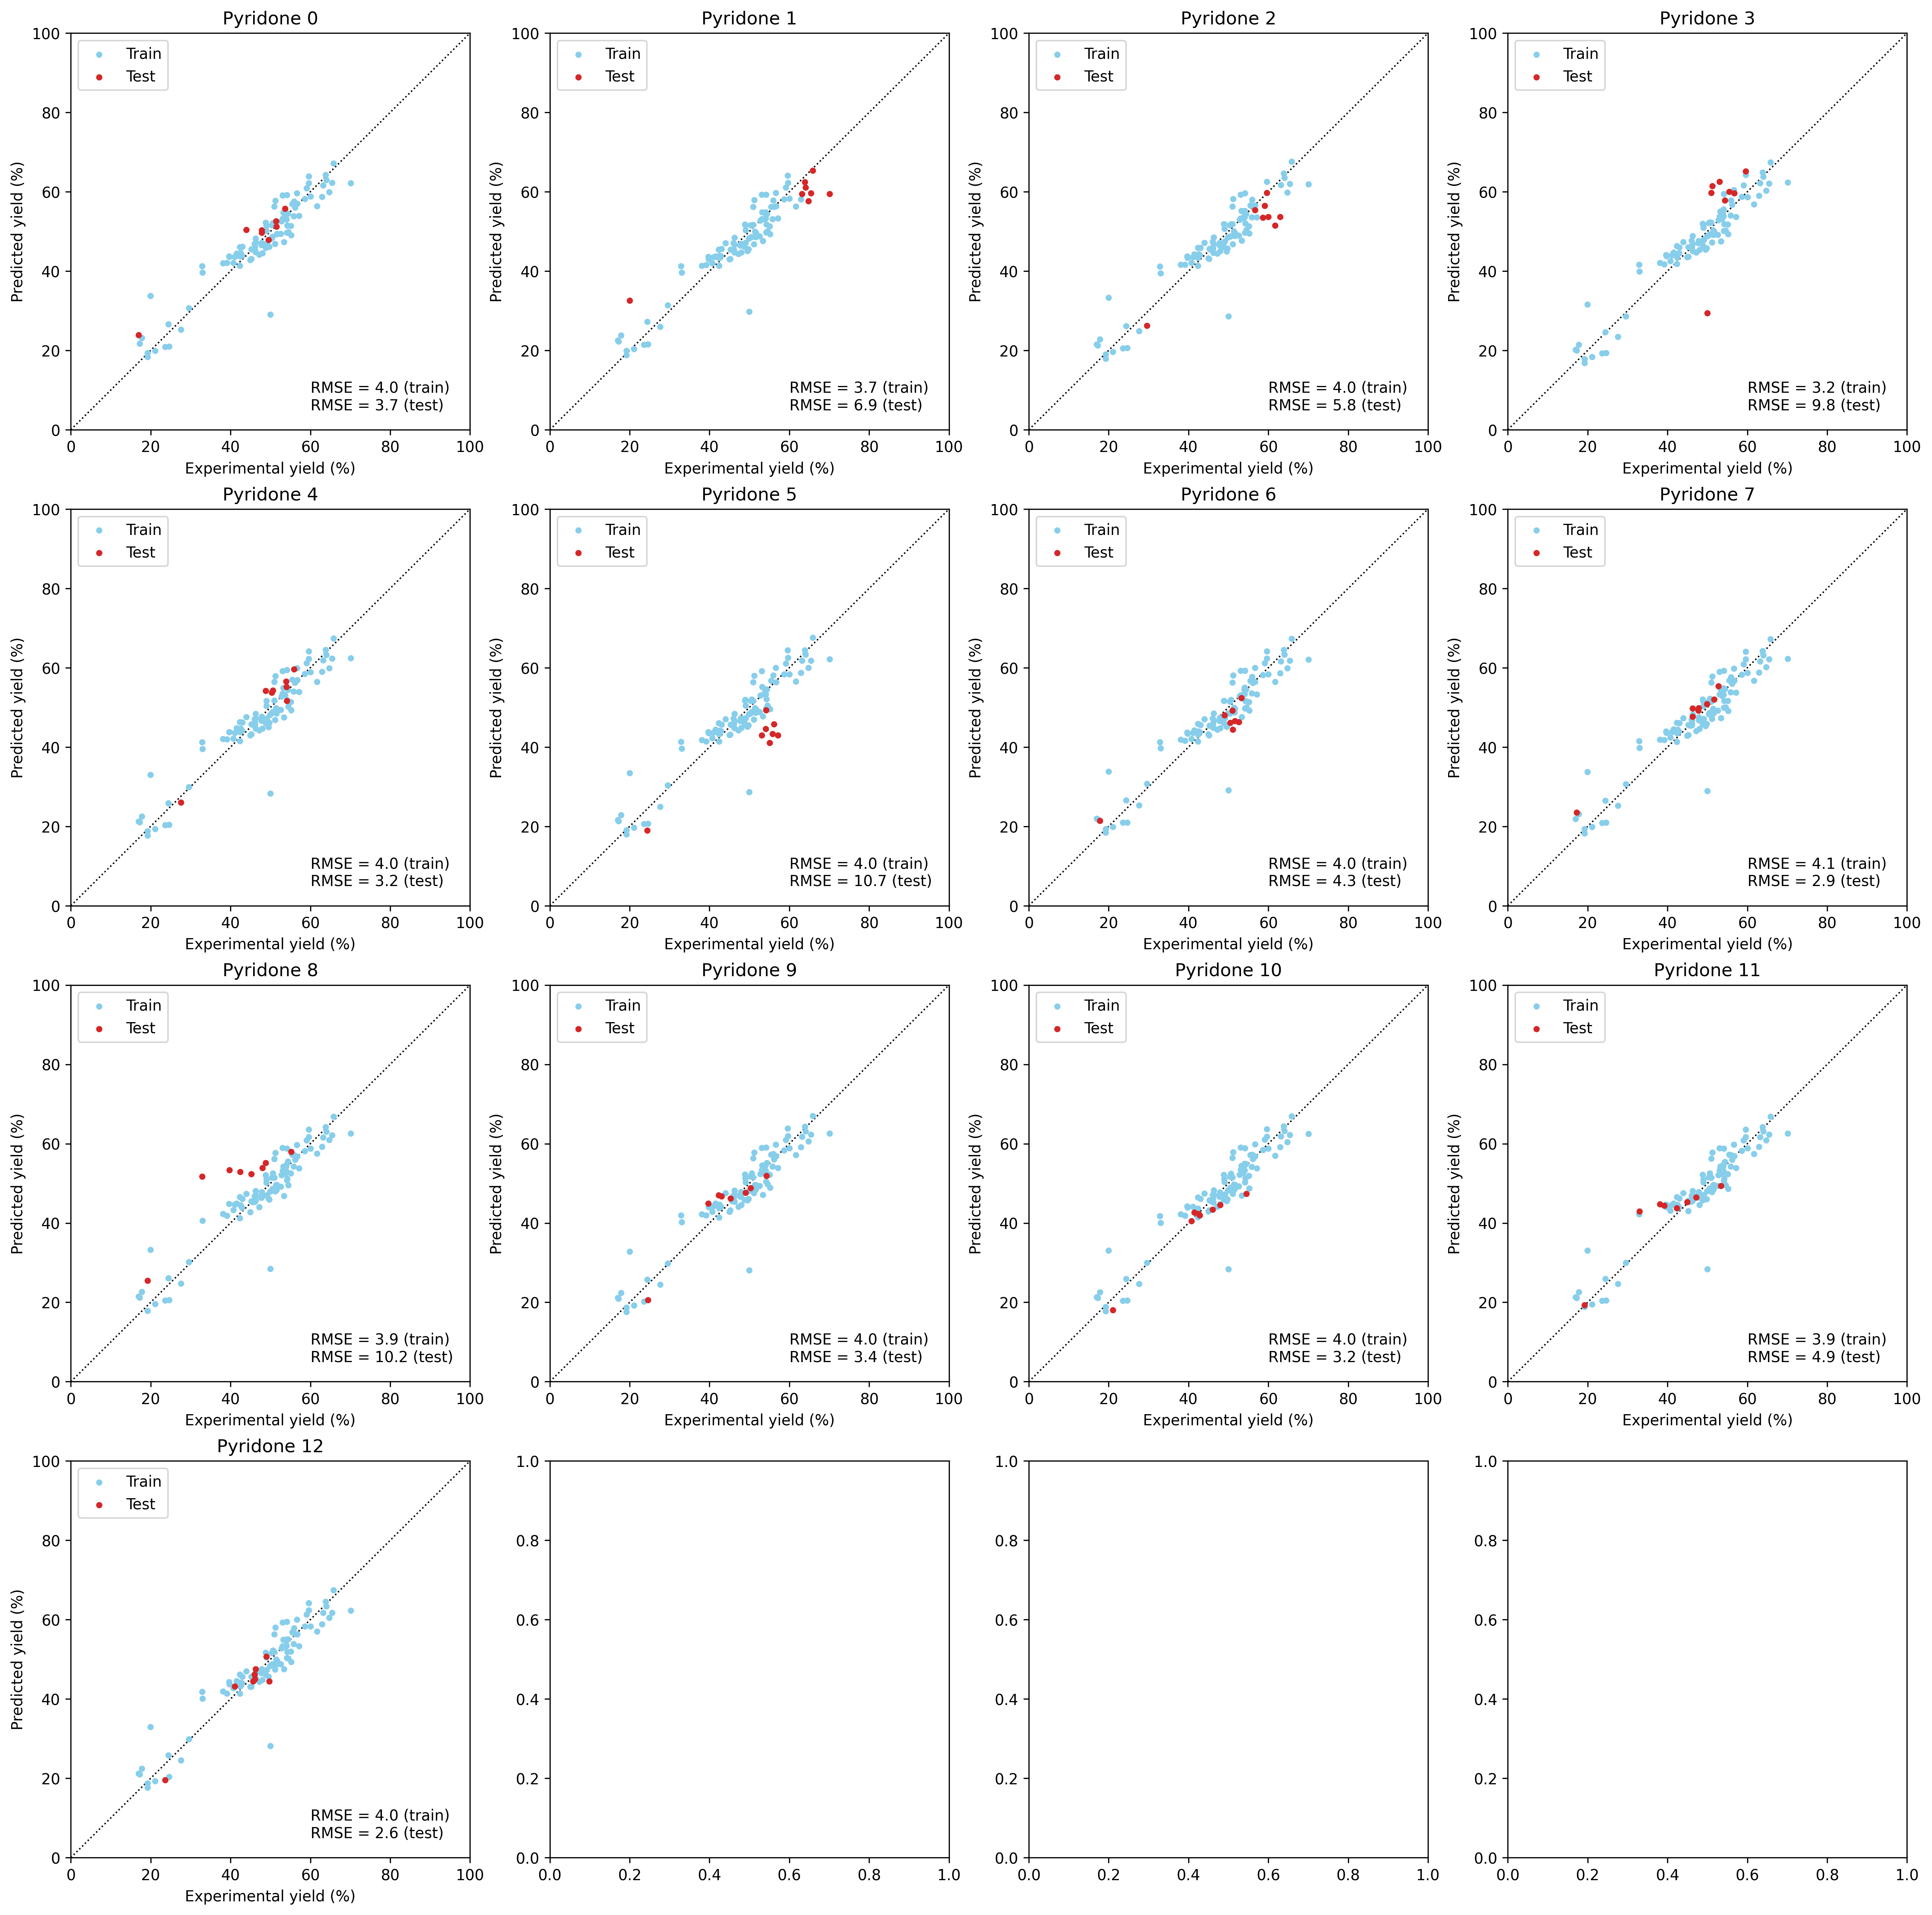

In [31]:
fig, axes = plt.subplots(4, 4, figsize=(22, 22), dpi=300)

for group_test in groups_test:
    df_train_val_min_ = df_train_val_min.filter(pl.col(f'{column_group}_test') == group_test)
    df_test_min_ = df_test_min.filter(pl.col(f'{column_group}_test') == group_test)
    df_train_val_min_rmse_ = df_train_val_min_rmse.filter(pl.col(f'{column_group}_test') == group_test)
    df_test_min_rmse_ = df_test_min_rmse.filter(pl.col(f'{column_group}_test') == group_test)
    
    div, mod = divmod(group_test, 4)
    
    axes[div, mod].plot(
        [0, 100],
        [0, 100],
        c="black",
        linestyle="dotted",
        lw=1,
        zorder=0
    )
    axes[div, mod].scatter(
        df_train_val_min_[column_target],
        df_train_val_min_[column_pred],
        c="skyblue",
        s=10,
        label="Train",
        zorder=1
    )
    axes[div, mod].scatter(
        df_test_min_[column_target],
        df_test_min_[column_pred],
        c="tab:red",
        s=10,
        label="Test",
        zorder=2
    )
    
    axes[div, mod].set_title(f"Pyridone {group_test}")
    axes[div, mod].set_xlabel("Experimental yield (%)")
    axes[div, mod].set_ylabel("Predicted yield (%)")
    axes[div, mod].set_xlim(0, 100)
    axes[div, mod].set_ylim(0, 100)
    
    axes[div, mod].legend()
    axes[div, mod].text(
        0.60, 0.05,
        f"RMSE = {df_train_val_min_rmse_[f'{column_target}_rmse'][0]:1.1f} (train)\n"
        f"RMSE = {df_test_min_rmse_[f'{column_target}_rmse'][0]:1.1f} (test)",
        transform=axes[div, mod].transAxes
    )
    
plt.savefig(
    f"{file_write}_scatter_each.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()